In [1]:
import fitsio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np


cat = fitsio.read("/home/vwetzell/Documents/ProperMotion/HealpixDetectionCatalog/cleaned_detections_hp07751.fits")
cat.dtype


dtype([('OBJECT_NUMBER', '>i4'), ('CCDNUM', '>i4'), ('NEW_RA', '>f8'), ('NEW_DEC', '>f8'), ('NEW_RA_ERR', '>f8'), ('NEW_DEC_ERR', '>f8'), ('HAS_UNIQUE_COLOR', 'i1'), ('BAND', '<U1'), ('FLAGS', '>i2'), ('FLUX_PSF', '>f4'), ('FLUXERR_PSF', '>f4'), ('SPREAD_MODEL', '>f4'), ('SPREADERR_MODEL', '>f4'), ('IMAFLAGS_ISO', '>i2'), ('ERRAWIN_WORLD', '>f4'), ('XWIN_IMAGE', '>f4'), ('YWIN_IMAGE', '>f4'), ('MAG_AUTO_G', '>f4'), ('MAG_AUTO_R', '>f4'), ('MAG_AUTO_I', '>f4'), ('MAG_AUTO_Z', '>f4'), ('MJD', '>f8'), ('PAR_XI', '>f8'), ('PAR_ETA', '>f8'), ('NEW_XWIN_IMAGE', '>f8'), ('NEW_YWIN_IMAGE', '>f8'), ('BEST_RA', '>f8'), ('BEST_DEC', '>f8'), ('DRA_DCOLOR', '>f8'), ('DDEC_DCOLOR', '>f8'), ('EXPNUM', '>i8'), ('ID', '>i8'), ('XI', '>f8'), ('ETA', '>f8'), ('DXI_DCOLOR', '>f8'), ('DETA_DCOLOR', '>f8')])

In [ ]:
plt.figure()
plt.hist(
    cat["NEW_RA_ERR"],
    bins=100,
    range=(0, 0.5),
    histtype="step",
)
plt.hist(
    cat["NEW_DEC_ERR"],
    bins=100,
    range=(0, 0.5),
    histtype="step",
)
plt.show()

In [74]:
from scipy.optimize import curve_fit


def func(mag, m50, sigma):
    return sigma * 10 ** (0.2 * (mag - m50)) * np.sqrt(1 + 10 ** (0.4 * (mag - m50)))


band = "z"

temp_cat = cat[cat["BAND"] == band]
temp_cat = temp_cat[
    (temp_cat[f"MAG_AUTO_{band.upper()}"] > 10)
    & (temp_cat[f"MAG_AUTO_{band.upper()}"] < 30)
]


def wavg_extended_class_y6a2(spread_model, spread_model_error):
    """DES DR2 extended classifier for stars and galaxies using WAVG quantities.

        0 : High-confidence stars
        1 : Likely stars
        2 : Likely galaxies
        3 : High-confidence galaxies
       -9 : Failures

    Parameters
    ----------
    spread_model      : SExtractor spread model value in a band
    spread_model_error: SExtractor spread model error in a band

    Returns
    -------
    extended_class    : Extended classifier output
    """
    extend_val = ((spread_model + 3.0 * spread_model_error) > 0.005) * 1
    extend_val += ((spread_model + 1.0 * spread_model_error) > 0.003) * 1
    extend_val += ((spread_model - 0.5 * spread_model_error) > 0.001) * 1

    extend_val[spread_model == -1] = -9
    extend_val[(spread_model == 0) & (spread_model_error == 0)] = -9
    extend_val[(spread_model == 1) & (spread_model_error == 1)] = -9
    return extend_val


star_mask = (
    wavg_extended_class_y6a2(temp_cat["SPREAD_MODEL"], temp_cat["SPREADERR_MODEL"]) <= 0
)

temp_cat = temp_cat[star_mask]

popt, pcov = curve_fit(
    func,
    temp_cat[f"MAG_AUTO_{band.upper()}"],
    temp_cat["ERRAWIN_WORLD"],
    p0=[20, 1e-6],
    # bounds=([15, 1e-8], [25, 1e-2]),
    sigma=temp_cat["ERRAWIN_WORLD"],
)

popt, pcov

(array([1.92882301e+01, 8.64428195e-07]),
 array([[9.10706718e-05, 5.24281974e-11],
        [5.24281974e-11, 3.16327994e-17]]))

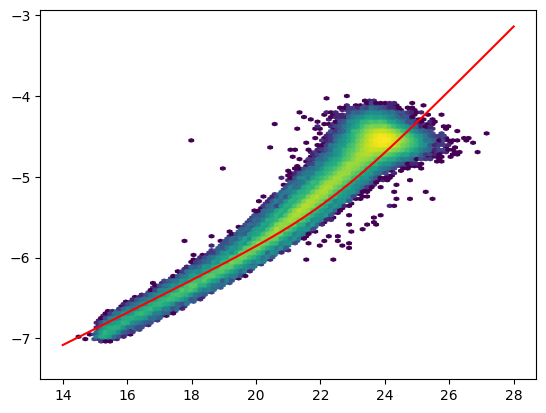

In [71]:

mag = np.linspace(14, 28, 100)
# err = func(mag, 20, 1e-6)
err = func(mag, *popt)

plt.figure()
plt.plot(mag, np.log10(err), color="red", label="Fitted Model")
plt.hexbin(
    temp_cat["MAG_AUTO_"+band.upper()],
    np.log10(temp_cat["ERRAWIN_WORLD"]),
    gridsize=100,
    norm=LogNorm(),
    mincnt=1,
    extent=(14, 28, -7.3, -4),
)
# plt.yscale("log")
# plt.xlim(14, 28)
# plt.ylim(0, 0.001)
plt.show()

In [76]:
fitsio.read("../data/y6a1.ccdcorners.fits.gz", ext=1)

array([(226650, 'S29',  1, 'z', 56520.19162437, [305.46716667, 305.92869043, 305.92695961, 305.46390694, 305.69676869], [-49.96093716, -49.96372585, -50.11067069, -50.10802381, -50.03613224]),
       (226650, 'S30',  2, 'z', 56520.19162437, [305.94950117, 306.41119893, 306.41081142, 305.94743253, 306.17986133], [-49.96387074, -49.96546456, -50.11241185, -50.11082643, -50.0383998 ]),
       (226650, 'S31',  3, 'z', 56520.19162437, [306.43226058, 306.89379891, 306.89538909, 306.43232633, 306.66359662], [-49.96478852, -49.96416907, -50.11125426, -50.11173829, -50.03828037]),
       ...,
       (810354, 'N28', 59, 'i', 58493.1717006 , [ 65.57966892,  65.89627053,  65.89677328,  65.5798999 ,  65.73828441], [-20.34196968, -20.34041614, -20.48756151, -20.48903946, -20.41491502]),
       (810354, 'N29', 60, 'i', 58493.1717006 , [ 64.75124031,  65.06831064,  65.06824721,  64.75093392,  64.90973904], [-20.50560869, -20.50656762, -20.65352679, -20.65270193, -20.57975371]),
       (810354, 'N31', 